In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [335]:
data = pd.read_csv("titanic.csv")

In [336]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [337]:
data['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [338]:
data['Embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

Start with Exploratory Data Analysis(EDA)

Sex vs Survival

Text(0, 0.5, 'Survival Probability')

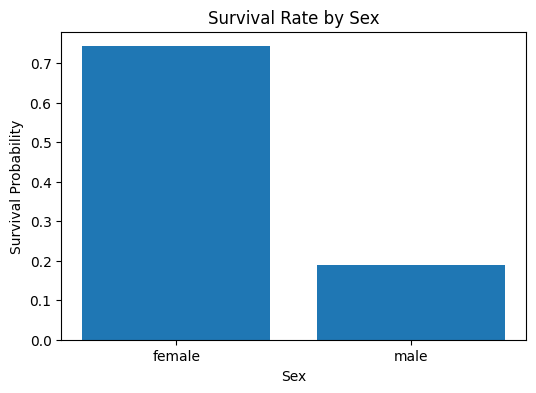

In [339]:
# Step 1: Figure setup
fig, ax = plt.subplots(figsize=(6,4))

# Step 2: Compute the Survival Rate
survival_rate = data.groupby("Sex")["Survived"].mean() # group all rows by the sex column like male and female groups but use the survived column only then find the mean.

# Step 3: Visualize
ax.bar(survival_rate.index, survival_rate.values)
ax.set_title("Survival Rate by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival Probability")

EDA 2   Pclass vs Survival

Text(0, 0.5, 'Survival Probability')

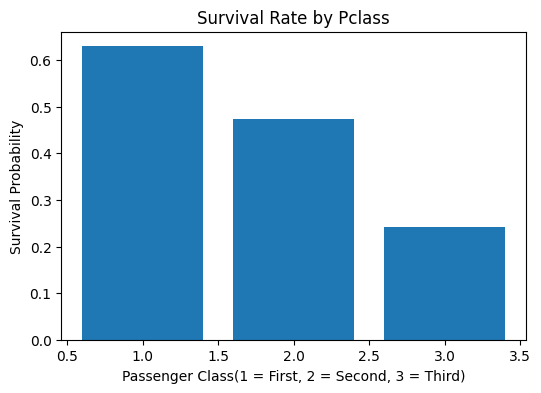

In [340]:
# Step 1: figure setup
fig, ax = plt.subplots(figsize=(6,4))

# Step 2: Compute Survival Rates Per Class
survival_rate = data.groupby("Pclass")["Survived"].mean()

# Step 3: Plot it
ax.bar(survival_rate.index, survival_rate.values)
ax.set_title("Survival Rate by Pclass")
ax.set_xlabel("Passenger Class(1 = First, 2 = Second, 3 = Third)")
ax.set_ylabel("Survival Probability")

EDA 3 Fare vs Survival

Text(0, 0.5, 'Survival Probability')

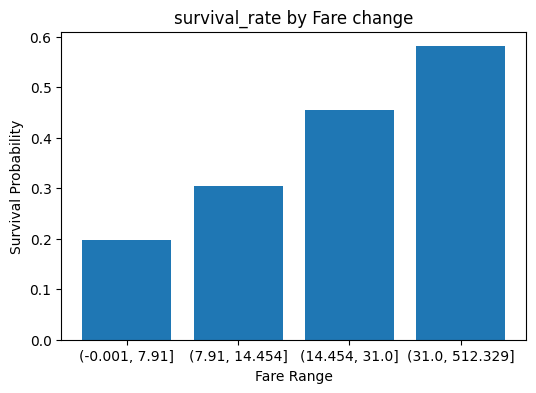

In [341]:
# Step 1: Setup figure
fig, ax = plt.subplots(figsize=(6,4))

# Step 2: Survival trend using fare(Grouped Insight)
data["Fare_bin"] = pd.qcut(data["Fare"], 4)
survival_rate = data.groupby("Fare_bin")["Survived"].mean()

# Step 3: Plotting
ax.bar(survival_rate.index.astype(str), survival_rate.values)
ax.set_title('survival_rate by Fare change')
ax.set_xlabel('Fare Range')
ax.set_ylabel("Survival Probability")

EDA 4 Age vs Survival

Text(0, 0.5, 'Survival Probability')

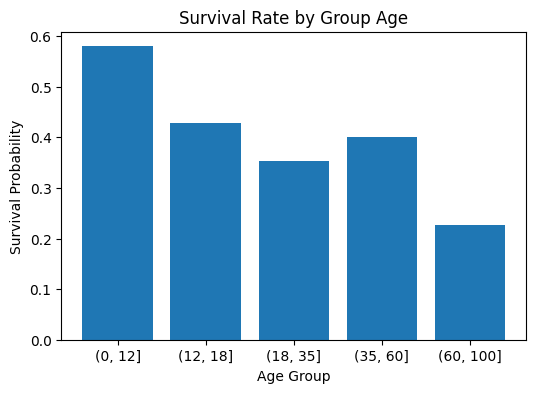

In [342]:
# Step 1: Handle missing age
data['Age'] = data['Age'].fillna(data['Age'].median())

# Step 2: bin Age
data['Age_bin'] = pd.cut(data['Age'], bins = [0, 12, 18, 35, 60, 100]) # child, teen, young adult, adult, elderly

# Step 3: Compute survival rate
survival_rate = data.groupby("Age_bin")["Survived"].mean()

# Step 4: Plot
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(survival_rate.index.astype(str), survival_rate.values)
ax.set_title("Survival Rate by Group Age")
ax.set_xlabel("Age Group")
ax.set_ylabel("Survival Probability")

EDA 5 Correlation Heat Map

In [343]:
# Step 1: Pick numeric features only
numeric_data = data[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch' ,'Fare']]

# Step 2: Compute Correlation Matrix
corr = numeric_data.corr()

In [344]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


Text(0.5, 1.0, 'Titanic Feature Correlation Heatmap')

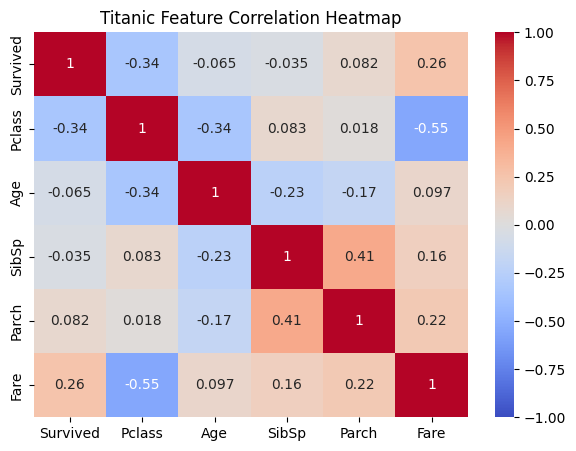

In [345]:
# Step 3: Plot
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title("Titanic Feature Correlation Heatmap")

Feature Selection + Final preprocessing Pipeline

1. Split the problem properly

In [346]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1 #Work with whole families not family relations

In [347]:
X = data[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize']]
y = data['Survived']

2. Encoding  Making data Machine Readable

In [348]:
# Binary Encoding for the Sex Column
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})


# Fill the Embarked column's missing values with the mode because we have a few missing values
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])


# Now do One hot encoding for the embarked column
embarked_dummies = pd.get_dummies(X['Embarked'], prefix='Embarked', dtype=int)
X = pd.concat([X, embarked_dummies], axis = 1)

In [349]:
X.head(3)

,Pclass,Sex,Age,Fare,Embarked,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,7.2500,S,2,0,0,1
1,1,1,38.0,71.2833,C,2,1,0,0
2,3,1,26.0,7.9250,S,1,0,0,1


In [350]:
X.head(3)

,Pclass,Sex,Age,Fare,Embarked,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,7.2500,S,2,0,0,1
1,1,1,38.0,71.2833,C,2,1,0,0
2,3,1,26.0,7.9250,S,1,0,0,1


In [351]:
X['Fare'] = np.log1p(X['Fare'])
X.head(3)

,Pclass,Sex,Age,Fare,Embarked,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,2.110213,S,2,0,0,1
1,1,1,38.0,4.280593,C,2,1,0,0
2,3,1,26.0,2.188856,S,1,0,0,1


In [352]:
X = X.drop('Embarked', axis = 1)

In [353]:
X.head(3)

,Pclass,Sex,Age,Fare,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,2.110213,2,0,0,1
1,1,1,38.0,4.280593,2,1,0,0
2,3,1,26.0,2.188856,1,0,0,1


In [354]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [355]:
X_train.head(3)

,Pclass,Sex,Age,Fare,FamilySize,Embarked_C,Embarked_Q,Embarked_S
331,1,0,45.5,3.384390,1,0,0,1
733,2,0,23.0,2.639057,1,0,0,1
382,3,0,32.0,2.188856,1,0,0,1


MODEL 1: Logistic Regression (Base Line)

In [356]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [357]:
y_pred = model.predict(X_test)

In [358]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")

Accuracy: 0.7988826815642458


Model Evaluation

1. Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix - Logistic Model')

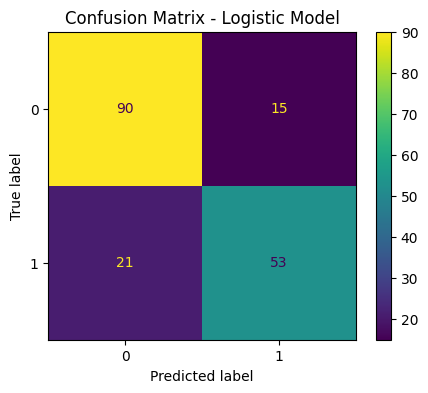

In [359]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Confusion Matrix - Logistic Model")

In [360]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



MODEL 2: Decision Tree

In [361]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [362]:
y_pred_tree = tree_model.predict(X_test)

In [363]:
from sklearn.metrics import accuracy_score, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, y_pred_tree)}")

Accuracy: 0.770949720670391


Text(0.5, 1.0, 'Confusion Matrix - Decision Tree Model')

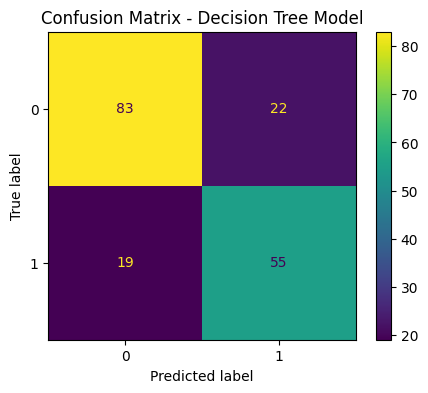

In [364]:
cm = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Confusion Matrix - Decision Tree Model")

MODEL 3: Random Forest

In [365]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [366]:
y_pred_rf = rf_model.predict(X_test)

In [367]:
print(f"Accuracy; {accuracy_score(y_test, y_pred_rf)}")

Accuracy; 0.8212290502793296


Text(0.5, 1.0, 'Confusion Matrix - Random Forest Model')

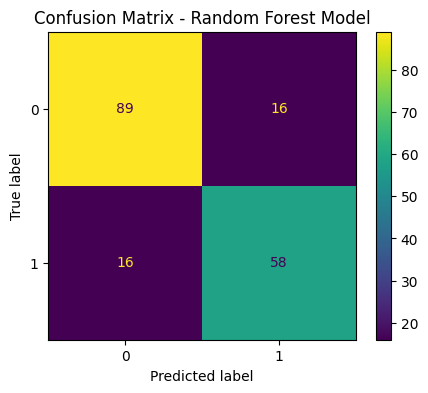

In [368]:
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Confusion Matrix - Random Forest Model")

MODEL 4: Neural Net

In [369]:
# Step 1: Make Sure X is fully numeric
X = X.astype(float)

# Step 2: Scale the Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.fit_transform(X_test)

In [370]:
import torch
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

Define the Model

In [371]:
import torch.nn as nn

class TitanicNN(nn.Module):
    def __init__(self, input_dim):
        super(TitanicNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

Initialize the Model

In [372]:
model = TitanicNN(X_train_tensor.shape[1])

Loss and Optimizer

In [373]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training Loop

In [374]:
epochs = 2000

for epoch in range(epochs):

    # Forward Pass
    y_pred = model(X_train_tensor)

    loss = criterion(y_pred, y_train_tensor)

    # Backward Pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.6582
Epoch 20, Loss: 0.6489
Epoch 30, Loss: 0.6385
Epoch 40, Loss: 0.6267
Epoch 50, Loss: 0.6132
Epoch 60, Loss: 0.5977
Epoch 70, Loss: 0.5798
Epoch 80, Loss: 0.5603
Epoch 90, Loss: 0.5400
Epoch 100, Loss: 0.5197
Epoch 110, Loss: 0.4999
Epoch 120, Loss: 0.4818
Epoch 130, Loss: 0.4660
Epoch 140, Loss: 0.4529
Epoch 150, Loss: 0.4423
Epoch 160, Loss: 0.4335
Epoch 170, Loss: 0.4262
Epoch 180, Loss: 0.4202
Epoch 190, Loss: 0.4152
Epoch 200, Loss: 0.4108
Epoch 210, Loss: 0.4071
Epoch 220, Loss: 0.4041
Epoch 230, Loss: 0.4016
Epoch 240, Loss: 0.3998
Epoch 250, Loss: 0.3983
Epoch 260, Loss: 0.3971
Epoch 270, Loss: 0.3960
Epoch 280, Loss: 0.3950
Epoch 290, Loss: 0.3941
Epoch 300, Loss: 0.3932
Epoch 310, Loss: 0.3924
Epoch 320, Loss: 0.3917
Epoch 330, Loss: 0.3910
Epoch 340, Loss: 0.3904
Epoch 350, Loss: 0.3898
Epoch 360, Loss: 0.3891
Epoch 370, Loss: 0.3884
Epoch 380, Loss: 0.3878
Epoch 390, Loss: 0.3871
Epoch 400, Loss: 0.3866
Epoch 410, Loss: 0.3860
Epoch 420, Loss: 0.3854
E

Prediction

In [375]:
with torch.no_grad():
    y_test_pred = model(X_test_tensor)
    y_test_pred_class = (y_test_pred > 0.5).float()

Evaluation

In [376]:
from sklearn.metrics import accuracy_score, confusion_matrix

acc = accuracy_score(y_test_tensor, y_test_pred_class)
print(f"PyTorch nn Accuracy: {acc}")

PyTorch nn Accuracy: 0.8100558659217877


Text(0.5, 1.0, 'Confusion Matrix - PyTorch NN Model')

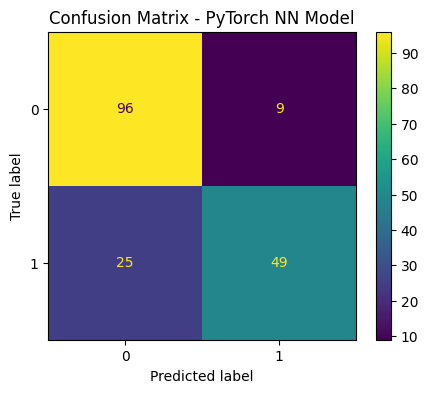

In [377]:
cm = confusion_matrix(y_test_tensor,  y_test_pred_class)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Confusion Matrix - PyTorch NN Model")

It is clear that all models are poor at predicting the True positives(who survived), indicating we need to further engineer our data if we want better results.